In [1]:
## Load my files ##
import sys
sys.path.append('..')
from utils import get_sequence

## Load standard files ##
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import torch.optim.lr_scheduler as lr_scheduler
from torch import from_numpy as tnsr
from scipy.stats import bernoulli
import torch.nn as nn
import numpy as np
import pandas as pd
from tqdm import tqdm
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.spatial.distance import cdist as dist
from sklearn.metrics.pairwise import cosine_similarity

In [2]:
n_community = 2
n_members = 3

tokens = []

for ii in range(n_community*n_members+1):
    tokens.append(
        chr(ord('A')+ii)
    )

In [232]:
class network_wake(nn.Module):
    def __init__(self, input_size, hidden_wake_size, hidden_sleep_size, num_layers=2, num_layers_sleep=2):
        super(network_wake, self).__init__()

        self.rnn = nn.RNN(input_size, hidden_wake_size, num_layers, nonlinearity='relu', batch_first=True)
        self.linear_sleep = nn.Linear(hidden_sleep_size*num_layers_sleep, len(tokens))
        self.wake_fc = nn.Linear(hidden_wake_size, len(tokens))

    def forward(self, x, hw=None, hs=None):        
        if hw == None:
            out, hw = self.rnn(x)
        else:
            out, hw = self.rnn(x, hw)

        out = self.wake_fc(out)
        
        if hs != None:
            # print('hi')
            # print(out.shape)
            sleep_out = self.linear_sleep(hs.view(-1)).view(1,1,-1)
            out = out + sleep_out
            # print(sleep_out.shape, out.shape)
        return out, hw

In [233]:
class network_sleep(nn.Module):
    def __init__(self, input_size, hidden_sleep_size, num_layers=1):
        super(network_sleep, self).__init__()

        self.rnn = nn.RNN(input_size, hidden_sleep_size, num_layers, nonlinearity='relu', batch_first=True)
        self.sleep_fc = nn.Linear(hidden_sleep_size, len(tokens))

    def forward(self, x, hs=None):
        if hs == None:
            out, hs = self.rnn(x)
        else:
            out, hs = self.rnn(x, hs)

        out = self.sleep_fc(out)
        
        return out, hs

In [234]:
class compressor(nn.Module):
    def __init__(self, input_size, hidden_compressor_size, num_layers=1):
        super(compressor, self).__init__()

        self.rnn = nn.RNN(input_size, hidden_compressor_size, num_layers, nonlinearity='relu', batch_first=True)
        self.compressor_fc = nn.Linear(hidden_compressor_size, 2)

    def forward(self, x, hc=None):
        if hc == None:
            out, hc = self.rnn(x)
        else:
            out, hc = self.rnn(x, hc)

        out = self.compressor_fc(out)
        
        return out, hc

In [235]:
def compute_geodesic(hidden1, hidden2):

    total_layers = len(hidden1)
    w = 0

    for ii in range(total_layers):
        w_ = np.array(dist( hidden1[ii], hidden2[ii], 'cosine'))
        w += w_
           
    return w[0][0]/total_layers

In [236]:
class Dataset_converter(Dataset):
    def __init__(self, data, working_memory=1, short_term_memory=8):
        
        one_hot_encoded = np.zeros((len(data), len(tokens)), dtype=float)
        for ii, token in enumerate(data):
            one_hot_encoded[ii,ord(token)-65] = 1
        
        self.X = np.zeros((((len(data)-working_memory-short_term_memory)), short_term_memory, len(tokens)*working_memory))
        self.y = np.zeros((((len(data)-working_memory-short_term_memory)), len(tokens)))

        for ii in range(self.X.shape[0]):
            for jj in range(self.X.shape[1]):
                for kk in range(working_memory):
                    self.X[ii,jj,kk*len(tokens):(kk+1)*len(tokens)] = \
                    one_hot_encoded[ii+jj+kk,:]
                    
            self.y[ii] = \
                one_hot_encoded[ii+jj+kk+1,:]

        self.X = tnsr(self.X).float()
        self.y = tnsr(self.y).float()

    def __getitem__(self, index):
        return self.X[index], self.y[index]

    def __len__(self):
        return self.X.shape[0]

In [237]:
class Dataset_converter_compressor(Dataset):
    def __init__(self, data, mask):
        total_sample = len(data)
        self.X = np.zeros((total_sample-2, len(tokens)))
        self.y = np.zeros((total_sample-2, 2))
        for ii in range(total_sample-2):
            token = data[ii]
            self.X[ii, ord(token)-65] = 1 
            self.y[ii,mask[ii]] = 1
            

        self.X = tnsr(self.X).float()
        self.y = tnsr(self.y).float()

    def __getitem__(self, index):
        return self.X[index], self.y[index]

    def __len__(self):
        return self.X.shape[0]

In [247]:
### initial training ###
total_samples = 40000
working_memory = 1
short_term_memory = 1
hidden_wake_size = 50
hidden_compressor_size = 10
hidden_sleep_size = 50
num_layers_wake = 1
num_layers_sleep = 1
output_sleep = len(tokens)
input_size = len(tokens)*working_memory
lr = 4e-4
test_acc = []

data = get_sequence(total_samples, n_community, n_members)
data_set = Dataset_converter(data, working_memory, short_term_memory)
train_loader = DataLoader(data_set, batch_size=1, shuffle=False)

network1 = network_wake(input_size, hidden_wake_size, hidden_sleep_size, num_layers_wake, num_layers_sleep)

optimizer = torch.optim.SGD(network1.parameters(), lr=lr, momentum=0.95)
criterion = torch.nn.CrossEntropyLoss()

total = 0
correct = np.zeros(1000,dtype=float)
for X, y in train_loader:
    optimizer.zero_grad()

    if total == 0:
        predicted_y, hidden = network1(X)
    else:
        predicted_y, hidden = network1(X, hw=mem)
        
    loss = criterion(predicted_y[0], y)
    loss.backward(retain_graph=True)
    optimizer.step()

    with torch.no_grad():
        mem=hidden.clone()
        true_y = y.argmax(axis=1)
        estimated_y = predicted_y.argmax(axis=2)

        total += 1
        if true_y == estimated_y:
                correct[total%1000] = 1
        else:
            correct[total%1000] = 0

        test_acc.append(
            np.sum(correct)/total if total<1000 else np.sum(correct)/1000
        )
        if total%1000 == 0:
            print(f'Iter : {total+1}, loss: {loss:.4f}, accuracy: {test_acc[-1]:.4f}')

Iter : 1001, loss: 1.8871, accuracy: 0.2000
Iter : 2001, loss: 2.0531, accuracy: 0.3550
Iter : 3001, loss: 1.7734, accuracy: 0.4450
Iter : 4001, loss: 1.9932, accuracy: 0.5710
Iter : 5001, loss: 2.1446, accuracy: 0.6810
Iter : 6001, loss: 3.2392, accuracy: 0.7080
Iter : 7001, loss: 0.6848, accuracy: 0.6910
Iter : 8001, loss: 1.5381, accuracy: 0.7250
Iter : 9001, loss: 1.1796, accuracy: 0.7260
Iter : 10001, loss: 1.7934, accuracy: 0.7210
Iter : 11001, loss: 1.5123, accuracy: 0.7440
Iter : 12001, loss: 2.0105, accuracy: 0.7220
Iter : 13001, loss: 1.9197, accuracy: 0.7330
Iter : 14001, loss: 1.2944, accuracy: 0.7270
Iter : 15001, loss: 0.8114, accuracy: 0.7510
Iter : 16001, loss: 1.8169, accuracy: 0.7460
Iter : 17001, loss: 1.9476, accuracy: 0.7560
Iter : 18001, loss: 1.4832, accuracy: 0.7380
Iter : 19001, loss: 2.1043, accuracy: 0.7540
Iter : 20001, loss: 1.5493, accuracy: 0.7550
Iter : 21001, loss: 2.1710, accuracy: 0.7690
Iter : 22001, loss: 1.4021, accuracy: 0.7550
Iter : 23001, loss:

In [248]:
predicted_y

tensor([[[ 4.0439, 10.3514, -1.2560,  1.6642,  2.2177, -6.3712, -8.8122]]],
       grad_fn=<ViewBackward0>)

In [249]:
compressor_sample = 10000

data_compressor = get_sequence(compressor_sample, n_community, n_members)
data_set_compressor = Dataset_converter(data_compressor, working_memory, short_term_memory)
compressor_loader = DataLoader(data_set_compressor, batch_size=1, shuffle=False) 

ii = 0
dis = [0]
# community = ''

with torch.no_grad():
    for X, _ in compressor_loader:
        if ii==0:
            id, hw = network1(X)
            id_current = hw
            # community = tokens[torch.argmax(X[0])]
        else:
            id, hw = network1(X, hw=hw)
            id_current = hw
            if ii>=1:
                dis.append(compute_geodesic(prev_id, id_current))
                # print(dis)
                # if dis[-1] >0.407:
                #     # print(dis, tokens[torch.argmax(X[0])])
                #     community += tokens[torch.argmax(X[0])]
                    
            
        prev_id = id_current
        ii += 1

In [250]:
dis_array = np.array(dis)
threshold = np.quantile(dis_array, .6)

mask = ((dis_array>threshold)*1)

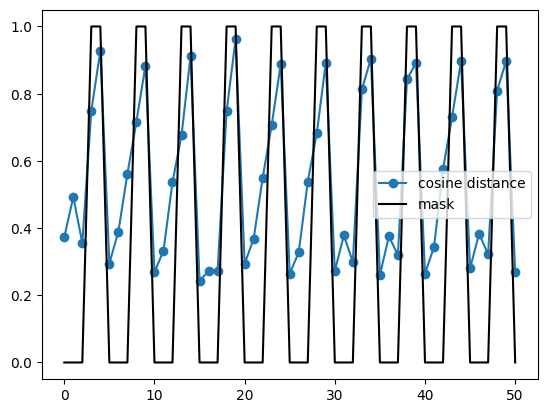

In [251]:
span = 51
plt.plot(dis[1:span+1], '-o', label='cosine distance')
plt.plot(mask[1:span+1], c='k', label = 'mask')
plt.legend()

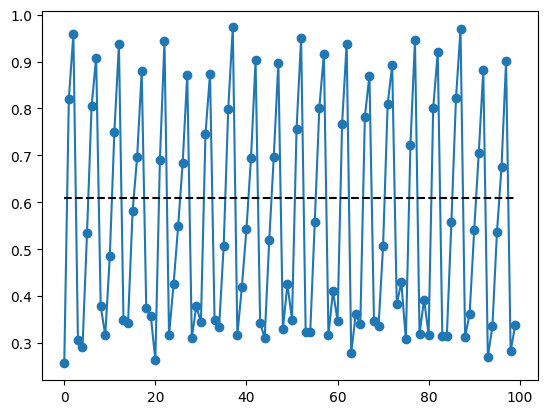

In [252]:
span = 100
plt.plot(dis[-span:], '-o')
plt.plot(np.arange(span), [threshold]*span, '--', c='k')

In [253]:
mask[-100:]

array([0, 1, 1, 0, 0, 0, 1, 1, 0, 0, 0, 1, 1, 0, 0, 0, 1, 1, 0, 0, 0, 1,
       1, 0, 0, 0, 1, 1, 0, 0, 0, 1, 1, 0, 0, 0, 1, 1, 0, 0, 0, 1, 1, 0,
       0, 0, 1, 1, 0, 0, 0, 1, 1, 0, 0, 0, 1, 1, 0, 0, 0, 1, 1, 0, 0, 0,
       1, 1, 0, 0, 0, 1, 1, 0, 0, 0, 1, 1, 0, 0, 0, 1, 1, 0, 0, 0, 1, 1,
       0, 0, 0, 1, 1, 0, 0, 0, 1, 1, 0, 0])

In [254]:
data_set = Dataset_converter_compressor(data_compressor, mask)
compressor_loader = DataLoader(data_set, batch_size=1, shuffle=False) 
compression = []

compressor_model = compressor(input_size, hidden_compressor_size)
optimizer = torch.optim.SGD(compressor_model.parameters(), lr=4e-3, momentum=0.95)
criterion = torch.nn.CrossEntropyLoss()

total = 0
correct = np.zeros(1000, dtype=float)
for X, y in compressor_loader:
    optimizer.zero_grad()

    if total == 0:
        predicted_y, hidden = compressor_model(X)
    else:
        predicted_y, hidden = compressor_model(X, hc=mem)
        
    loss = criterion(predicted_y, y)
    loss.backward()
    optimizer.step()

    with torch.no_grad():
        mem = hidden.clone()

        true_y = y.argmax(axis=1)
        estimated_y = predicted_y.argmax(axis=1)

        if estimated_y[0]:
            compression.append((true_y[0],estimated_y[0],tokens[X.argmax(axis=1)]))
            
        total += 1
        if true_y == estimated_y:
            correct[total%1000] = 1
        else:
            correct[total%1000] = 0

        test_acc.append(
            np.sum(correct)/total if total<1000 else np.sum(correct)/1000
        )
        if total%1000 == 0:
            print(f'Iter : {total+1}, loss: {loss:.4f}, accuracy: {test_acc[-1]:.4f}')



Iter : 1001, loss: 0.0021, accuracy: 0.9420
Iter : 2001, loss: 0.0024, accuracy: 0.9990
Iter : 3001, loss: 0.0029, accuracy: 1.0000
Iter : 4001, loss: 0.0003, accuracy: 1.0000
Iter : 5001, loss: 0.0002, accuracy: 1.0000
Iter : 6001, loss: 0.0011, accuracy: 1.0000
Iter : 7001, loss: 0.0001, accuracy: 1.0000
Iter : 8001, loss: 0.0001, accuracy: 1.0000
Iter : 9001, loss: 0.0001, accuracy: 1.0000


In [255]:
compressed_seq = ''
data = get_sequence(3000, n_community, n_members, train=False)
data_test = Dataset_converter_compressor(data, mask)
test_loader = DataLoader(data_test, batch_size=1, shuffle=False) 

total = 0
correct = np.zeros(1000, dtype=float)
for X, y in test_loader:      

    with torch.no_grad():
        if total == 0:
            predicted_y, hidden = compressor_model(X)
        else:
            predicted_y, hidden = compressor_model(X, hc=hidden)


        # if total<8:
        #     print(X)
        # print(y, predicted_y)
        true_y = y.argmax(axis=1)
        estimated_y = predicted_y.argmax(axis=1)

        if estimated_y[0]:
            compressed_seq += tokens[X.argmax(axis=1)]
            
        total += 1

In [256]:
compressed_seq

'GDGDGCGDGEGFGDGFGFGEGCGCGFGCGCGAGCGAGDGBGEGFGBGAGFGEGDGEGCGEGCGFGBGFGFGCGFGEGCGCGFGCGDGEGEGDGEGAGEGBGFGDGDGEGAGFGBGBGFGDGAGEGBGFGAGAGAGCGCGEGEGBGBGAGDGDGAGFGCGAGEGAGEGFGFGEGDGDGBGDGDGCGBGDGCGAGDGEGAGFGAGBGDGAGBGAGDGEGAGFGAGAGBGBGBGEGAGFGCGFGEGDGDGDGCGFGEGFGFGCGFGDGCGCGFGCGCGCGBGEGDGBGAGEGBGEGDGDGEGBGAGAGEGBGEGEGDGCGDGAGCGFGAGDGFGCGCGDGBGFGBGEGAGDGBGDGCGCGBGEGCGFGBGFGAGAGBGAGBGDGAGBGFGBGBGCGDGBGBGEGAGDGCGBGFGFGBGBGCGDGFGAGAGCGBGCGFGAGFGBGCGCGDGEGEGAGBGEGFGDGEGAGCGBGDGEGAGFGCGBGEGAGEGFGFGFGBGAGCGFGEGEGBGEGDGEGDGAGCGFGEGCGAGBGEGEGBGFGEGDGEGFGAGCGCGFGCGEGCGEGEGCGAGCGFGBGBGEGEGFGDGAGDGAGBGCGBGEGFGFGCGEGAGBGEGFGEGDGDGEGCGBGDGDGEGDGEGDGFGDGEGEGCGAGBGAGFGEGFGBGDGEGFGEGFGEGFGAGBGAGBGEGDGCGDGAGBGFGCGDGAGFGAGBGBGAGEGFGDGBGDGCGEGCGAGAGBGFGDGFGCGEGCGAGDGEGFGAGDGEGCGFGCGDGDGBGAGEGEGCGEGFGFGDGDGEGBGBGEGAGEGCGAGFGEGDGFGDGCGDGFGFGCGAGFGFGBGFGEGDGCGAGBGEGAGCGAGBGBGCGEGFGFGCGBGDGDGEGAGDGBGDGBGFGFGDGBGFGBGBGEGAGFGAGBGFGAGCGAGBGCGBGBGCGCGDGAGEGDGCGFGFGEGAGAGDGDGDGDGAGEGAGDGAGBGAGBGEGEGFGDGFGAGEGBGDGAGEGAG

In [257]:
sleep_samples = 40000
compressed_seq = ''
data_sleep = get_sequence(sleep_samples, n_community, n_members)
data_set_sleep = Dataset_converter(data_sleep, working_memory, short_term_memory)

sleep_loader = DataLoader(data_set_sleep, batch_size=1, shuffle=False)
network2 = network_sleep(input_size, hidden_sleep_size, num_layers_sleep)

optimizer = torch.optim.SGD(network2.parameters(), lr=lr, momentum=0.95)
criterion = torch.nn.CrossEntropyLoss()

total = 0
total_ = 0
sleep_mem = None
correct = np.zeros(1000,dtype=float)
for X, y in sleep_loader:

    with torch.no_grad():
        if total == 0:
            y_ = X.clone()
            predicted_y, hidden = compressor_model(X[0])
        else:
            predicted_y, hidden = compressor_model(X[0], hc=hidden)

        selection = predicted_y.argmax(axis=1)

        if selection:
            sleep = True
            compressed_seq += data_sleep[total]
            X_ = y_.clone()
            y_ = X.clone()
            # print(X_,y_)
        else:
            sleep = False

        total += 1
    ####################################################################
    if sleep:
        optimizer.zero_grad()
        if total_ == 0:
            predicted_y, hidden_s = network2(X_)
        else:
            predicted_y, hidden_s = network2(X_, hs=mem)
            
        loss = criterion(predicted_y[0], y_[0])
        loss.backward(retain_graph=True)
        optimizer.step()
        

        with torch.no_grad():
            mem=hidden_s.clone()
            
            true_y = y_[0].argmax(axis=1)
            estimated_y = predicted_y.argmax(axis=2)

            total_ += 1
            if true_y == estimated_y:
                correct[total_%1000] = 1
            else:
                correct[total_%1000] = 0

            test_acc.append(
                np.sum(correct)/total_ if total_<1000 else np.sum(correct)/1000
            )
            if total_%1000 == 0:
                print(f'Iter : {total_+1}, loss: {loss:.4f}, accuracy: {test_acc[-1]:.4f}')

Iter : 1001, loss: 0.0143, accuracy: 0.5240
Iter : 2001, loss: 0.0016, accuracy: 0.6260
Iter : 3001, loss: 0.0017, accuracy: 0.6360
Iter : 4001, loss: 0.0014, accuracy: 0.6170
Iter : 5001, loss: 0.0016, accuracy: 0.6210
Iter : 6001, loss: 0.0014, accuracy: 0.6360
Iter : 7001, loss: 0.0010, accuracy: 0.6430
Iter : 8001, loss: 0.0009, accuracy: 0.6100
Iter : 9001, loss: 0.0006, accuracy: 0.6340
Iter : 10001, loss: 0.0009, accuracy: 0.6290
Iter : 11001, loss: 0.0008, accuracy: 0.6240
Iter : 12001, loss: 0.0006, accuracy: 0.6330
Iter : 13001, loss: 0.0009, accuracy: 0.6210
Iter : 14001, loss: 0.0006, accuracy: 0.6190
Iter : 15001, loss: 0.0005, accuracy: 0.6240


In [258]:
compressed_seq[-100:]

'GEGDGEGAGBGAGBGAGEGEGEGEGAGEGEGAGDGBGDGBGBGDGDGEGEGDGBGAGDGDGDGDGBGDGEGEGEGEGBGAGAGDGDGDGDGEGAGEGEGB'

In [259]:
wake_samples = 50000
compressed_seq = ''
data_wake = get_sequence(wake_samples, n_community, n_members)
data_set_wake = Dataset_converter(data_wake, working_memory, short_term_memory)

wake_loader = DataLoader(data_set_wake, batch_size=1, shuffle=False)

optimizer = torch.optim.SGD(network1.parameters(), lr=lr, momentum=0.95)
criterion = torch.nn.CrossEntropyLoss()

total = 0
total_ = 0
sleep_mem = None
correct = np.zeros(1000,dtype=float)
for X, y in wake_loader:

    with torch.no_grad():
        if total == 0:
            predicted_y, hidden = compressor_model(X[0])
        else:
            predicted_y, hidden = compressor_model(X[0], hc=hidden)

        selection = predicted_y.argmax(axis=1)

        if selection:
            compressed_seq += data_wake[total]

            if total_ == 0:
                predicted_y_, hidden_s = network2(X)
            else:
                predicted_y_, hidden_s = network2(X, hidden_s)
            
            total_ += 1
    ####################################################################
    optimizer.zero_grad()

    if total == 0:
        predicted_y, hidden_wake = network1(X)
    else:
        if total_ == 0:
            predicted_y, hidden_wake = network1(X, hw=mem)
        else:
            predicted_y, hidden_wake = network1(X, hw=mem, hs=hidden_s)
        
    loss = criterion(predicted_y[0], y)
    loss.backward()
    optimizer.step()

    with torch.no_grad():
        total += 1
        mem=hidden_wake.clone()
        true_y = y.argmax(axis=1)
        estimated_y = predicted_y.argmax(axis=2)

        if true_y == estimated_y:
            # print(true_y, estimated_y)
            correct[total%1000] = 1
            # print(total, correct)
            # break
        else:
            correct[total%1000] = 0

        test_acc.append(
            np.sum(correct)/total if total<1000 else np.sum(correct)/1000
        )
        if total%1000 == 0:
            print(f'Iter : {total+1}, loss: {loss:.4f}, accuracy: {test_acc[-1]:.4f}')
            # break 
        

Iter : 1001, loss: 1.5797, accuracy: 0.7390
Iter : 2001, loss: 1.4016, accuracy: 0.7340
Iter : 3001, loss: 1.1561, accuracy: 0.7450
Iter : 4001, loss: 1.5307, accuracy: 0.7550
Iter : 5001, loss: 1.6267, accuracy: 0.7510
Iter : 6001, loss: 1.7006, accuracy: 0.7450
Iter : 7001, loss: 1.0481, accuracy: 0.7460
Iter : 8001, loss: 1.3895, accuracy: 0.7530
Iter : 9001, loss: 1.2106, accuracy: 0.7520
Iter : 10001, loss: 1.4352, accuracy: 0.7570
Iter : 11001, loss: 1.2410, accuracy: 0.7520
Iter : 12001, loss: 1.1440, accuracy: 0.7490
Iter : 13001, loss: 1.2671, accuracy: 0.7550
Iter : 14001, loss: 1.4737, accuracy: 0.7450
Iter : 15001, loss: 1.2162, accuracy: 0.7450
Iter : 16001, loss: 1.7635, accuracy: 0.7390
Iter : 17001, loss: 0.9217, accuracy: 0.7530
Iter : 18001, loss: 1.7634, accuracy: 0.7660
Iter : 19001, loss: 1.4127, accuracy: 0.7320
Iter : 20001, loss: 1.5296, accuracy: 0.7290
Iter : 21001, loss: 1.9227, accuracy: 0.7520
Iter : 22001, loss: 1.4184, accuracy: 0.7660
Iter : 23001, loss:

In [260]:
compressed_seq[-100:]

'GDGEGDGBGEGEGAGBGEGEGDGBGBGEGBGEGDGDGDGBGAGBGEGAGEGEGEGAGBGEGDGEGDGDGEGAGAGBGEGDGAGDGBGAGEGAGDGBGDGB'

In [85]:
hidden_s

tensor([[[0.0459, 0.0000, 0.6723, 0.3365, 1.9492, 0.0000, 0.5561, 0.0000,
          1.1868, 0.1972, 0.0000, 0.0000, 0.1026, 0.2560, 0.3014, 0.6244,
          0.0000, 0.4378, 1.3136, 0.3423, 0.0000, 0.0000, 0.6369, 0.6849,
          0.3200, 1.6163, 0.0000, 0.0000, 0.0000, 0.8338, 0.0000, 0.0000,
          0.0000, 2.0887, 0.2951, 2.8361, 0.0000, 0.0000, 0.0000, 0.0802,
          0.3542, 0.0000, 0.0000, 0.0629, 0.3468, 0.0000, 1.2369, 0.0000,
          0.0000, 0.3619]]])

In [287]:
predicted_y_

tensor([[[-1.6646, -1.6087, -0.2201, -2.2594, -2.2511, -0.3330,  8.0937]]])

In [288]:
X

tensor([[[0., 0., 0., 0., 0., 1., 0.]]])

In [202]:
predicted_y

tensor([[[ 0.3027,  8.0883,  0.7656, -1.2318, -4.1577, -5.5672, -0.7501]]],
       grad_fn=<ViewBackward0>)

In [203]:
y

tensor([[0., 1., 0., 0., 0., 0., 0.]])